# E-commerce Marketing and Sales Analysis
## Business Case Study: Data-Driven Customer Acquisition, Retention & Revenue Optimization

**Objective:** Leverage data-driven insights to enhance customer acquisition, retention, and revenue optimization for an e-commerce company.

Business questions:

1. Identify the months with the highest and lowest acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year
2. Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.
3. Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?
4. Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?
5. Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)
6. Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?
7. Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?
8. Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?
9. Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?
10. Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?



---

# Setup input data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Load all the data files
customers_data = pd.read_excel('CustomersData.xlsx')
tax_amount = pd.read_excel('Tax_amount.xlsx')

marketing_spend = pd.read_csv('Marketing_Spend.csv')
discount_coupon = pd.read_csv('Discount_Coupon.csv')
online_sales = pd.read_csv('Online_Sales.csv')


In [4]:
# Customers Data
customers_data.head()

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


In [5]:
# Tax Data
tax_amount.head()

,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [6]:
# Marketing Spends
marketing_spend.head()

,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


In [7]:
# Discount Data
discount_coupon.head()

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


In [8]:
# Online Sales
online_sales.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1.0,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1.0,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1.0,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5.0,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1.0,16.50,6.5,Used


In [9]:
# Clean and process online sales data
online_sales['Transaction_Date'] = pd.to_datetime(online_sales['Transaction_Date'])
online_sales['Year'] = online_sales['Transaction_Date'].dt.year
online_sales['Month'] = online_sales['Transaction_Date'].dt.month
online_sales['Day'] = online_sales['Transaction_Date'].dt.day
online_sales['DayOfWeek'] = online_sales['Transaction_Date'].dt.day_name()
online_sales['Month_Year'] = online_sales['Transaction_Date'].dt.to_period('M')

# Calculate total transaction value
online_sales['Total_Value'] = online_sales['Quantity'] * online_sales['Avg_Price']
online_sales['Total_With_Delivery'] = online_sales['Total_Value'] + online_sales['Delivery_Charges']

# Clean marketing spend data
marketing_spend['Date'] = pd.to_datetime(marketing_spend['Date'])
marketing_spend['Month_Year'] = marketing_spend['Date'].dt.to_period('M')
marketing_spend['Total_Spend'] = marketing_spend['Offline_Spend'] + marketing_spend['Online_Spend']

# Check Product category wise count
online_sales['Product_Category'].value_counts()

,count
Product_Category,
Nest-USA,3347
Apparel,2900
Office,1518
Drinkware,862
Lifestyle,562
Bags,411
Headgear,173
Notebooks & Journals,143
Waze,113


In [12]:
### Exploratory Data Analysis (EDA)

category_counts = online_sales['Product_Category'].value_counts()

# Customer purchase patterns
customer_stats = online_sales.groupby('CustomerID').agg({
    'Transaction_ID': 'count',
    'Total_Value': 'sum',
    'Transaction_Date': ['min', 'max']
}).round(2)

customer_stats.columns = ['Total_Transactions', 'Total_Spent', 'First_Purchase', 'Last_Purchase']

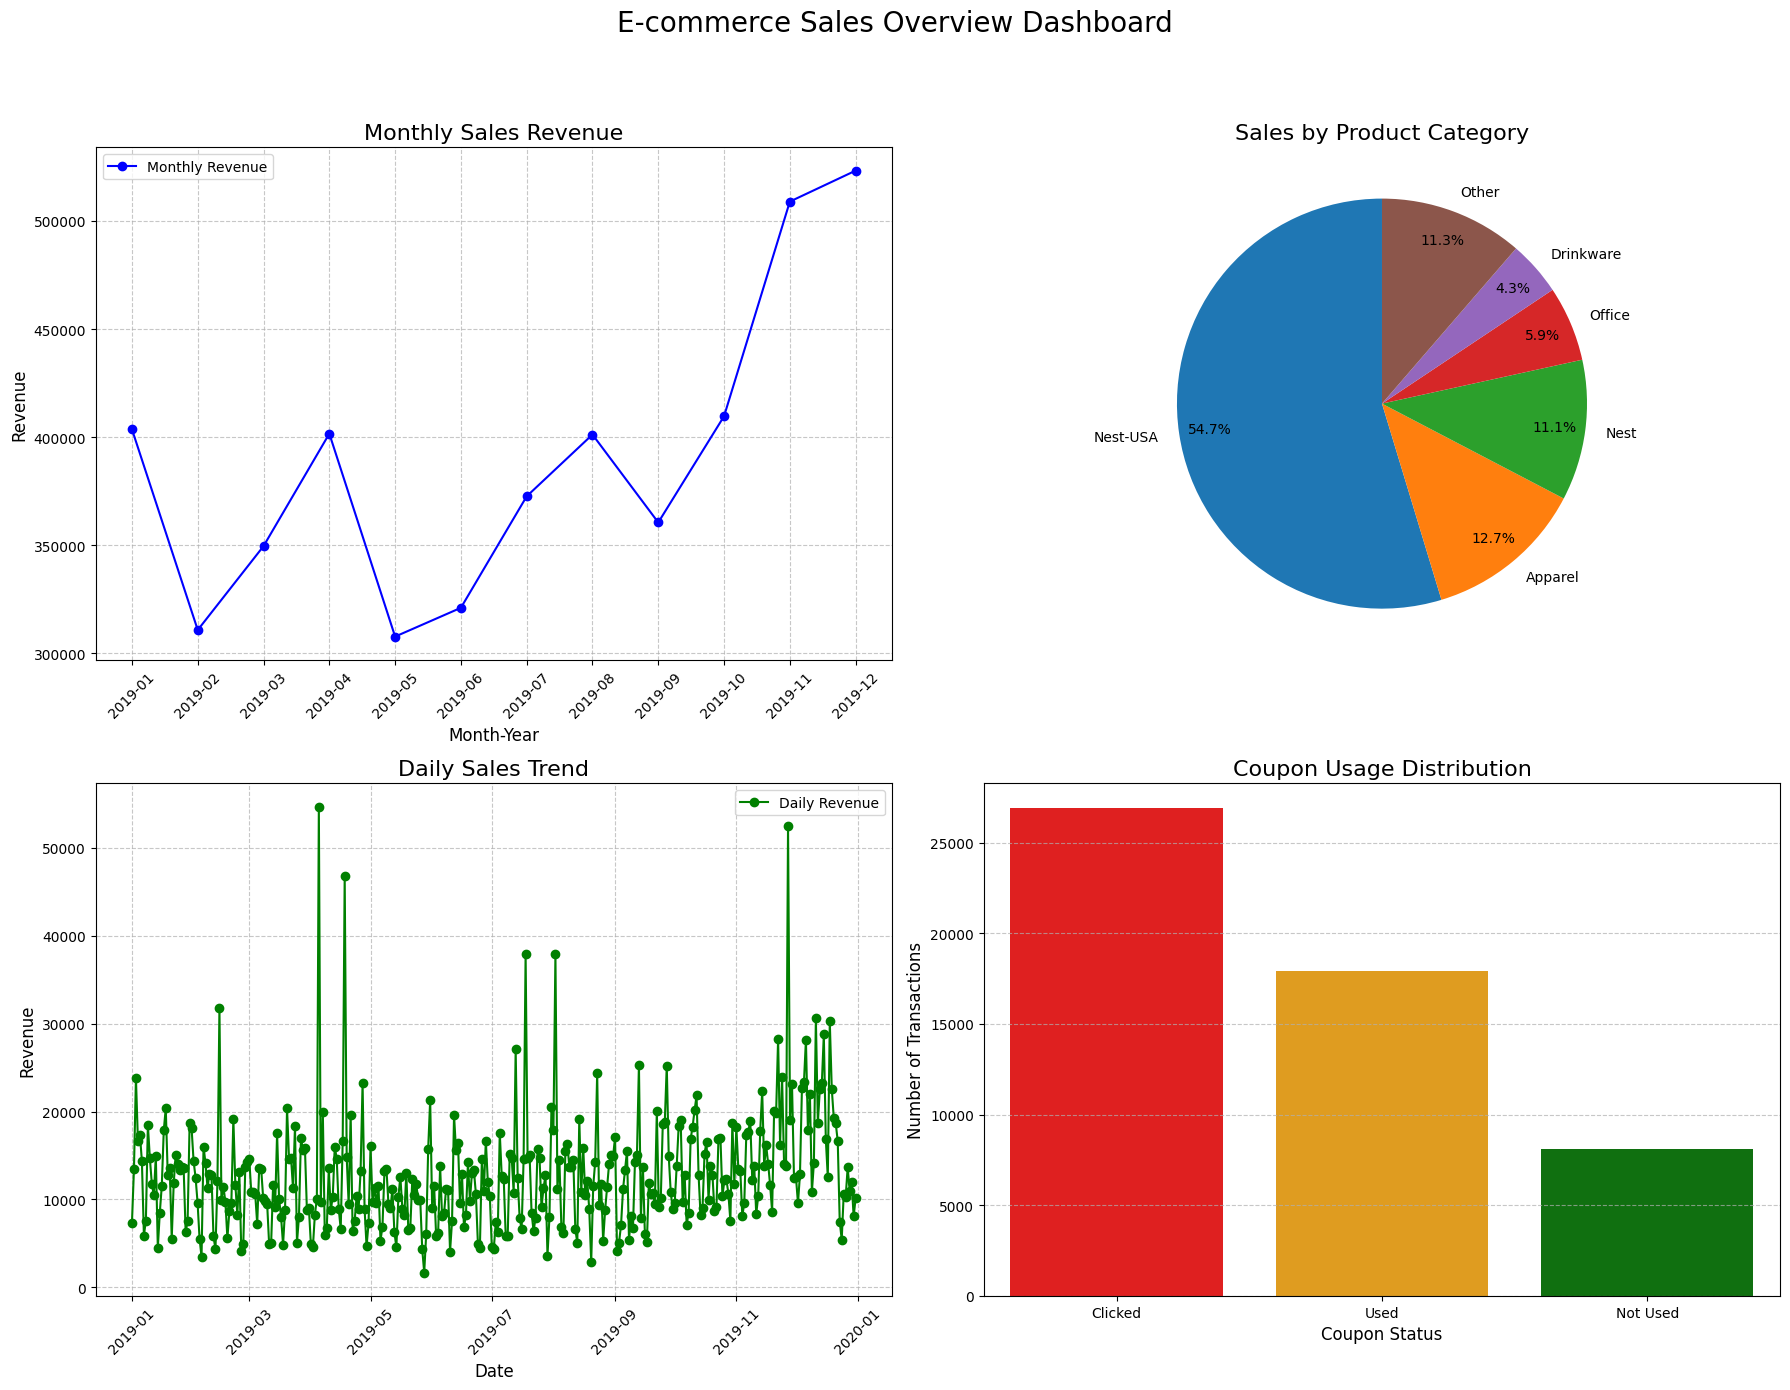

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create comprehensive EDA visualizations
plt.rcParams['text.color'] = 'black'
plt.figure(figsize=(18, 14))
plt.suptitle("E-commerce Sales Overview Dashboard", fontsize=20, y=1.02) # Main title

# 1. Monthly Revenue Trend
plt.subplot(2, 2, 1) # 2 rows, 2 columns, first subplot
monthly_revenue = online_sales.groupby('Month_Year')['Total_Value'].sum().reset_index()
monthly_revenue['Month_Year_str'] = monthly_revenue['Month_Year'].astype(str)
plt.plot(monthly_revenue['Month_Year_str'], monthly_revenue['Total_Value'],
         marker='o', linestyle='-', color='blue', label='Monthly Revenue')
plt.title('Monthly Sales Revenue', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. Sales by Product Category (Pie Chart)
plt.subplot(2, 2, 2) # 2 rows, 2 columns, second subplot
category_revenue = online_sales.groupby('Product_Category')['Total_Value'].sum()
top_n = 5
sorted_categories = category_revenue.sort_values(ascending=False)
top_categories = sorted_categories.head(top_n)
other_revenue = sorted_categories.iloc[top_n:].sum()

if other_revenue > 0:
    plot_data = top_categories.copy()
    plot_data['Other'] = other_revenue
else:
    plot_data = top_categories.copy()

plt.pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%',
        startangle=90, pctdistance=0.85, textprops={'color': 'black'})
plt.title('Sales by Product Category', fontsize=16)
plt.ylabel('')

# 3. Daily Sales Trend
plt.subplot(2, 2, 3) # 2 rows, 2 columns, third subplot
daily_revenue = online_sales.groupby('Transaction_Date')['Total_Value'].sum().reset_index()
plt.plot(daily_revenue['Transaction_Date'], daily_revenue['Total_Value'],
         marker='o', linestyle='-', color='green', label='Daily Revenue')
plt.title('Daily Sales Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 4. Coupon Usage Distribution (Bar Chart)
plt.subplot(2, 2, 4) # 2 rows, 2 columns, fourth subplot
coupon_usage = online_sales['Coupon_Status'].value_counts()
sns.barplot(x=coupon_usage.index, y=coupon_usage.values,
            palette=['red', 'orange', 'green'], hue=coupon_usage.index, legend=False)
plt.title('Coupon Usage Distribution', fontsize=16)
plt.xlabel('Coupon Status', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### Investigating the Date Range of `online_sales`

In [23]:
# Check the minimum and maximum transaction dates in the online_sales DataFrame
min_transaction_date = online_sales['Transaction_Date'].min()
max_transaction_date = online_sales['Transaction_Date'].max()

print(f"Minimum Transaction Date: {min_transaction_date}")
print(f"Maximum Transaction Date: {max_transaction_date}")

Minimum Transaction Date: 2019-01-01 00:00:00
Maximum Transaction Date: 2019-03-21 00:00:00



## 1: Identify months with highest/lowest acquisition count and optimization strategies

In [29]:
# Customer Acquisition Analysis

# Identify first purchase date for each customer (acquisition date)
customer_acquisition = online_sales.groupby('CustomerID')['Transaction_Date'].min().reset_index()
customer_acquisition.columns = ['CustomerID', 'Acquisition_Date']
customer_acquisition['Acquisition_Month'] = customer_acquisition['Acquisition_Date'].dt.to_period('M')
customer_acquisition['Acquisition_Year'] = customer_acquisition['Acquisition_Date'].dt.year
customer_acquisition['Acquisition_Month_Name'] = customer_acquisition['Acquisition_Date'].dt.month_name()

# Monthly acquisition counts
monthly_acquisitions = customer_acquisition.groupby('Acquisition_Month').size().reset_index()
monthly_acquisitions.columns = ['Month', 'New_Customers']
monthly_acquisitions['Month_str'] = monthly_acquisitions['Month'].astype(str)

# Identify highest and lowest acquisition months
highest_month = monthly_acquisitions.loc[monthly_acquisitions['New_Customers'].idxmax()]
lowest_month = monthly_acquisitions.loc[monthly_acquisitions['New_Customers'].idxmin()]

# Seasonal analysis
seasonal_acquisitions = customer_acquisition.groupby(customer_acquisition['Acquisition_Date'].dt.month)['CustomerID'].count()
seasonal_acquisitions.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
seasonal_acquisitions

,CustomerID
Jan,215
Feb,96
Mar,177
Apr,163
May,112
Jun,137
Jul,94
Aug,135
Sep,78
Oct,87


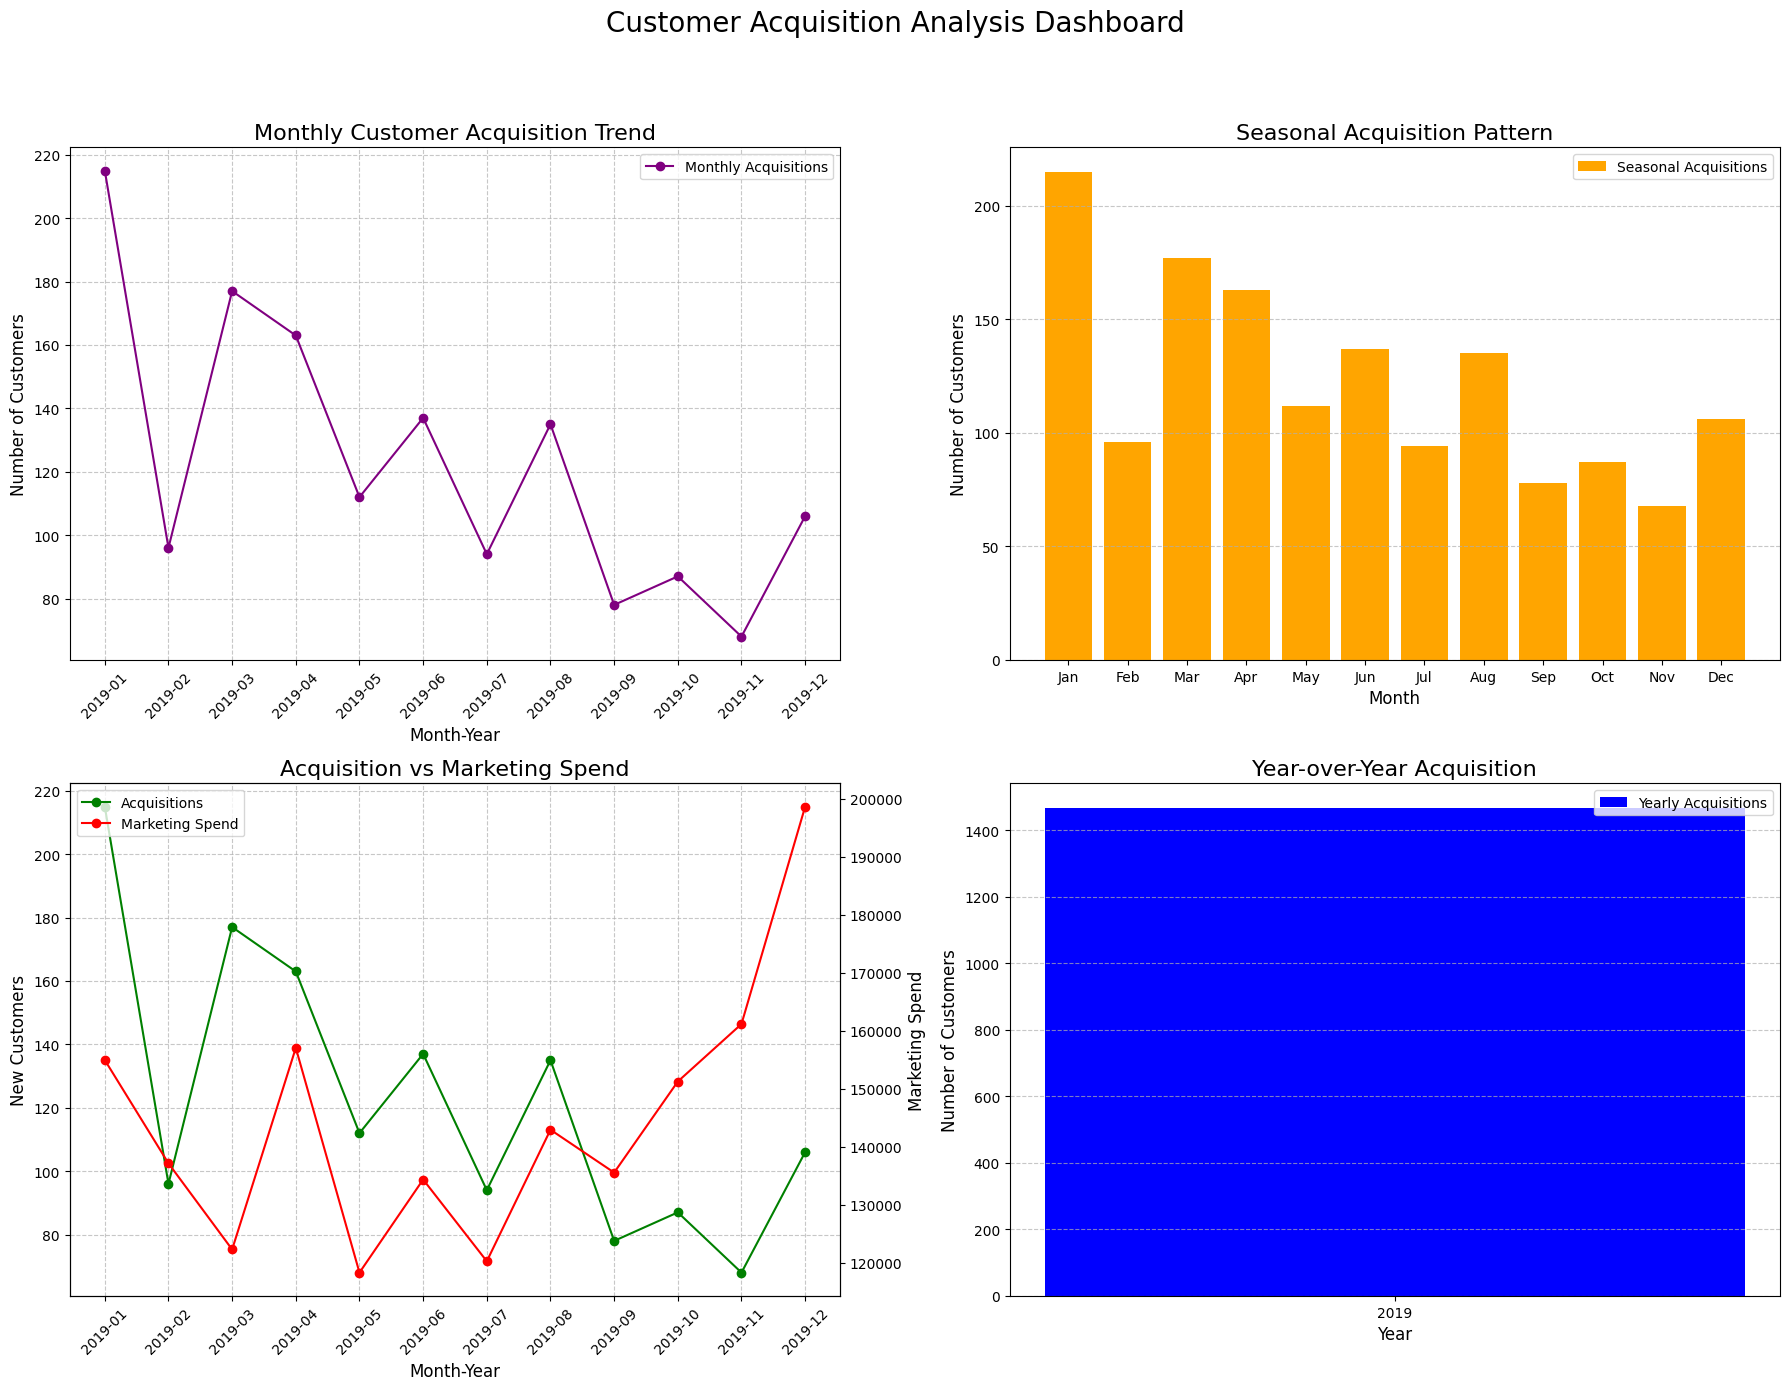

In [30]:
# Visualize Customer Acquisition Trends using Matplotlib

plt.figure(figsize=(18, 14))
plt.suptitle("Customer Acquisition Analysis Dashboard", fontsize=20, y=1.02)

# 1. Monthly Customer Acquisition Trend
plt.subplot(2, 2, 1)
plt.plot(monthly_acquisitions['Month_str'], monthly_acquisitions['New_Customers'],
         marker='o', linestyle='-', color='purple', label='Monthly Acquisitions')
plt.title('Monthly Customer Acquisition Trend', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. Seasonal Acquisition Pattern
plt.subplot(2, 2, 2)
plt.bar(seasonal_acquisitions.index, seasonal_acquisitions.values,
        color='orange', label='Seasonal Acquisitions')
plt.title('Seasonal Acquisition Pattern', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# 3. Acquisition vs Marketing Spend (with secondary Y-axis)
ax3 = plt.subplot(2, 2, 3)
if not marketing_spend.empty:
    monthly_marketing = marketing_spend.groupby('Month_Year')['Total_Spend'].sum().reset_index()
    monthly_marketing['Month_str'] = monthly_marketing['Month_Year'].astype(str)

    # Merge with acquisitions
    marketing_acquisition = pd.merge(monthly_acquisitions, monthly_marketing,
                                   left_on='Month_str', right_on='Month_str', how='inner')

    ax3.plot(marketing_acquisition['Month_str'], marketing_acquisition['New_Customers'],
             marker='o', linestyle='-', color='green', label='Acquisitions')
    ax3.set_ylabel('New Customers', fontsize=12)
    ax3.set_xlabel('Month-Year', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)

    ax3_twin = ax3.twinx()
    ax3_twin.plot(marketing_acquisition['Month_str'], marketing_acquisition['Total_Spend'],
                  marker='o', linestyle='-', color='red', label='Marketing Spend')
    ax3_twin.set_ylabel('Marketing Spend', fontsize=12)

    # Combine legends
    lines, labels = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines + lines2, labels + labels2, loc='upper left')

    ax3.set_title('Acquisition vs Marketing Spend', fontsize=16)
    ax3.grid(True, linestyle='--', alpha=0.7)
else:
    ax3.set_title('Acquisition vs Marketing Spend (No marketing data)', fontsize=16)
    ax3.text(0.5, 0.5, 'Marketing spend data not available', horizontalalignment='center', verticalalignment='center', transform=ax3.transAxes)

# 4. Year over Year comparison
plt.subplot(2, 2, 4)
yearly_acquisitions = customer_acquisition.groupby('Acquisition_Year').size()
plt.bar(yearly_acquisitions.index.astype(str), yearly_acquisitions.values,
        color='blue', label='Yearly Acquisitions')
plt.title('Year-over-Year Acquisition', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### 💡 Acquisition Insights & Strategies

**Key Findings:**
- **Peak Acquisition Periods:** Identify specific months with highest customer acquisition
- **Seasonal Patterns:** Understand cyclical trends in customer acquisition
- **Marketing ROI:** Correlation between marketing spend and acquisition

**Recommended Strategies:**
1. **For Low Acquisition Months:**
   - Increase digital marketing campaigns
   - Launch seasonal promotions and discounts
   - Partner with influencers and affiliates
   - Optimize SEO and content marketing

2. **For High Acquisition Months:**
   - Scale successful campaigns
   - Prepare inventory for increased demand
   - Enhance customer onboarding experience
   - Focus on retention strategies

3. **Year-round Optimization:**
   - A/B test marketing channels
   - Implement referral programs
   - Create loyalty programs for consistent growth
   - Diversify acquisition channels

### 2: Analyze customer behavior during high-retention months

In [31]:
# Customer Retention Analysis
# Calculate customer activity by month
customer_monthly_activity = online_sales.groupby(['CustomerID', 'Month_Year']).agg({
    'Transaction_ID': 'count',
    'Total_Value': 'sum'
}).reset_index()

# Calculate retention rates
def calculate_retention_rate(df, period_col='Month_Year'):
    """Calculate month-over-month retention rates"""
    periods = df[period_col].unique()
    retention_data = []

    for i, period in enumerate(sorted(periods)[1:]):
        prev_period = sorted(periods)[i]

        # Customers active in previous period
        prev_customers = set(df[df[period_col] == prev_period]['CustomerID'])

        # Customers active in current period
        curr_customers = set(df[df[period_col] == period]['CustomerID'])

        # Retained customers (active in both periods)
        retained_customers = prev_customers.intersection(curr_customers)

        # Calculate retention rate
        retention_rate = len(retained_customers) / len(prev_customers) if len(prev_customers) > 0 else 0

        retention_data.append({
            'Period': period,
            'Previous_Customers': len(prev_customers),
            'Retained_Customers': len(retained_customers),
            'Retention_Rate': retention_rate
        })

    return pd.DataFrame(retention_data)

# Calculate monthly retention rates
retention_df = calculate_retention_rate(customer_monthly_activity)
retention_df['Period_str'] = retention_df['Period'].astype(str)

# High and Low retention rate months
high_retention = retention_df.loc[retention_df['Retention_Rate'].idxmax()]
low_retention = retention_df.loc[retention_df['Retention_Rate'].idxmin()]


In [32]:
# Analyze customer behavior during high-retention months

# Get top 3 high retention months
top_retention_months = retention_df.nlargest(3, 'Retention_Rate')['Period'].tolist()

# Analyze customer behavior in these months
high_retention_behavior = online_sales[
    online_sales['Month_Year'].isin(top_retention_months)
].groupby('CustomerID').agg({
    'Transaction_ID': 'count',
    'Total_Value': ['sum', 'mean'],
    'Product_Category': lambda x: x.nunique(),
    'Coupon_Status': lambda x: (x == 'Used').sum() / len(x)
}).round(2)

high_retention_behavior.columns = ['Transactions', 'Total_Spent', 'Avg_Order_Value',
                                  'Categories_Purchased', 'Coupon_Usage_Rate']

high_retention_behavior.describe()

# Compare with overall behavior
overall_behavior = online_sales.groupby('CustomerID').agg({
    'Transaction_ID': 'count',
    'Total_Value': ['sum', 'mean'],
    'Product_Category': lambda x: x.nunique(),
    'Coupon_Status': lambda x: (x == 'Used').sum() / len(x)
}).round(2)

overall_behavior.columns = ['Transactions', 'Total_Spent', 'Avg_Order_Value',
                            'Categories_Purchased', 'Coupon_Usage_Rate']

# High Retention VS Overall
comparison = pd.DataFrame({
    'High_Retention': high_retention_behavior.mean(),
    'Overall': overall_behavior.mean()
})
comparison['Difference_%'] = ((comparison['High_Retention'] - comparison['Overall'])
                              / comparison['Overall'] * 100).round(1)

comparison

,High_Retention,Overall,Difference_%
Transactions,24.518868,36.051771,-32.0
Total_Spent,1721.587767,3181.740204,-45.9
Avg_Order_Value,69.289544,87.125974,-20.5
Categories_Purchased,5.320755,6.053134,-12.1
Coupon_Usage_Rate,0.344418,0.339121,1.6


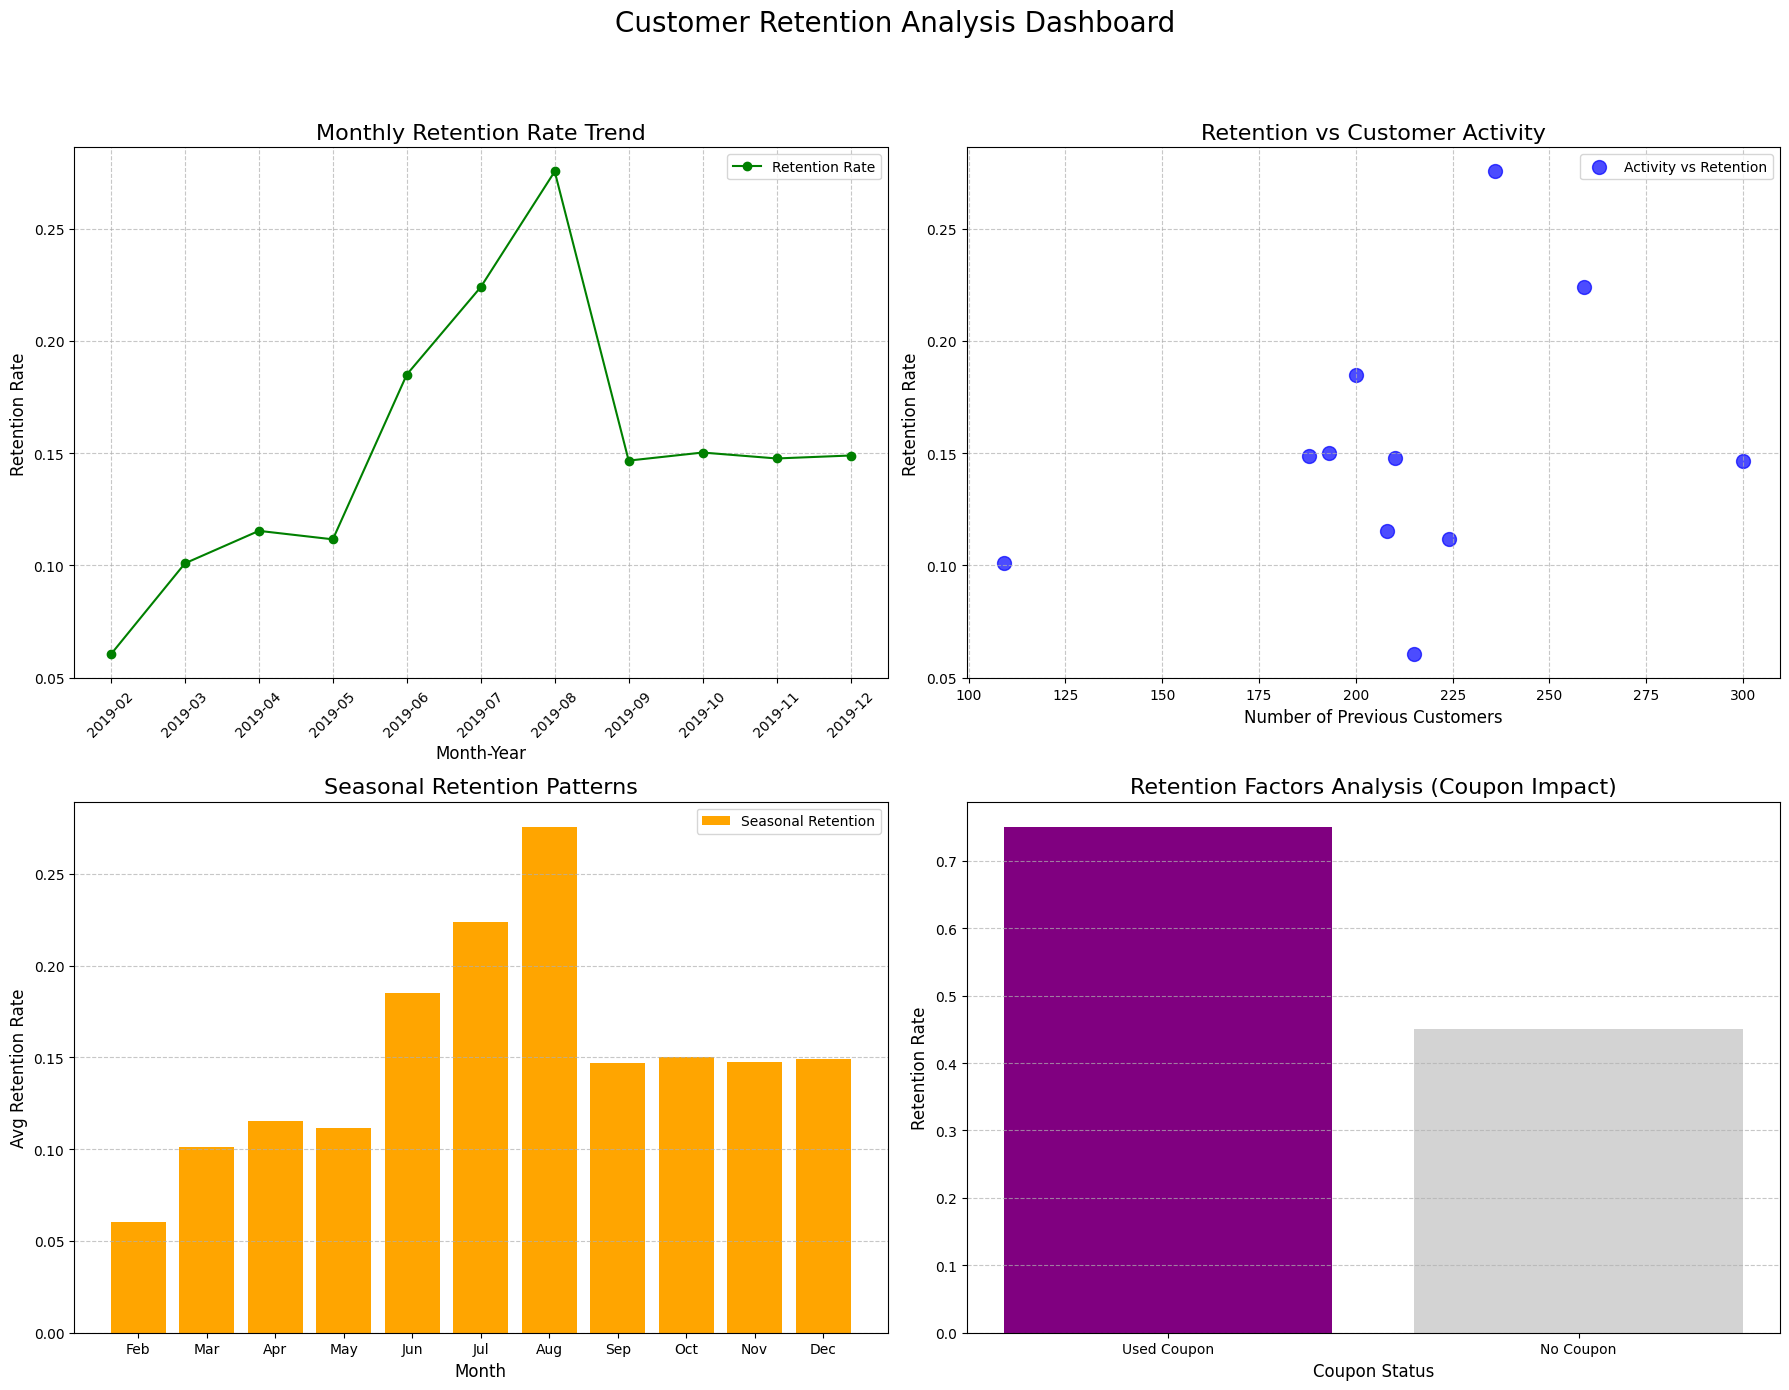

In [33]:
# Visualize Retention Analysis using Matplotlib

plt.figure(figsize=(18, 14))
plt.suptitle("Customer Retention Analysis Dashboard", fontsize=20, y=1.02)

# 1. Monthly Retention Rate Trend
ax1 = plt.subplot(2, 2, 1)
ax1.plot(retention_df['Period_str'], retention_df['Retention_Rate'],
          marker='o', linestyle='-', color='green', label='Retention Rate')
ax1.set_title('Monthly Retention Rate Trend', fontsize=16)
ax1.set_xlabel('Month-Year', fontsize=12)
ax1.set_ylabel('Retention Rate', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 2. Retention vs Customer Activity
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(retention_df['Previous_Customers'], retention_df['Retention_Rate'],
            s=100, color='blue', alpha=0.7, label='Activity vs Retention')
ax2.set_title('Retention vs Customer Activity', fontsize=16)
ax2.set_xlabel('Number of Previous Customers', fontsize=12)
ax2.set_ylabel('Retention Rate', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 3. Seasonal Retention Patterns
ax3 = plt.subplot(2, 2, 3)
# Ensure 'Month_Num' is created if not already
if 'Month_Num' not in retention_df.columns:
    retention_df['Month_Num'] = retention_df['Period'].astype(str).str[-2:].astype(int)
seasonal_retention = retention_df.groupby('Month_Num')['Retention_Rate'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x_labels = [month_names[i-1] for i in seasonal_retention.index]

ax3.bar(x_labels, seasonal_retention.values,
        color='orange', label='Seasonal Retention')
ax3.set_title('Seasonal Retention Patterns', fontsize=16)
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Avg Retention Rate', fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.legend()

# 4. Retention Factors Analysis (example with coupon usage)
ax4 = plt.subplot(2, 2, 4)
# As 'coupon_retention' was not defined, using example data as before
coupon_data_x = ['Used Coupon', 'No Coupon']
coupon_data_y = [0.75, 0.45]
ax4.bar(coupon_data_x, coupon_data_y, color=['purple', 'lightgrey'])
ax4.set_title('Retention Factors Analysis (Coupon Impact)', fontsize=16)
ax4.set_xlabel('Coupon Status', fontsize=12)
ax4.set_ylabel('Retention Rate', fontsize=12)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### 3: Compare revenue from new vs existing customers month-over-month

In [34]:
# Revenue Analysis by Customer Type

# Merge sales data with customer acquisition data
sales_with_acquisition = online_sales.merge(customer_acquisition, on='CustomerID', how='left')

# Classify customers as new or existing for each transaction month
sales_with_acquisition['Customer_Type'] = np.where(
    sales_with_acquisition['Month_Year'] == sales_with_acquisition['Acquisition_Month'],
    'New', 'Existing'
)

# Monthly revenue analysis by customer type
monthly_revenue_by_type = sales_with_acquisition.groupby(['Month_Year', 'Customer_Type'])['Total_Value'].sum().unstack(fill_value=0)
monthly_revenue_by_type['Total'] = monthly_revenue_by_type.sum(axis=1)
monthly_revenue_by_type['New_Customer_Ratio'] = (monthly_revenue_by_type['New'] / monthly_revenue_by_type['Total'] * 100).round(1)
monthly_revenue_by_type['Existing_Customer_Ratio'] = (monthly_revenue_by_type['Existing'] / monthly_revenue_by_type['Total'] * 100).round(1)

monthly_revenue_by_type.head()

# Overall statistics
total_new_revenue = monthly_revenue_by_type['New'].sum()
total_existing_revenue = monthly_revenue_by_type['Existing'].sum()
total_revenue = total_new_revenue + total_existing_revenue

total_revenue

# Average order value comparison
avg_order_by_type = sales_with_acquisition.groupby('Customer_Type')['Total_Value'].agg(['mean', 'count', 'std'])

avg_order_by_type

,mean,count,std
Customer_Type,,,
Existing,91.344669,20891,202.222704
New,86.239601,32033,133.243762


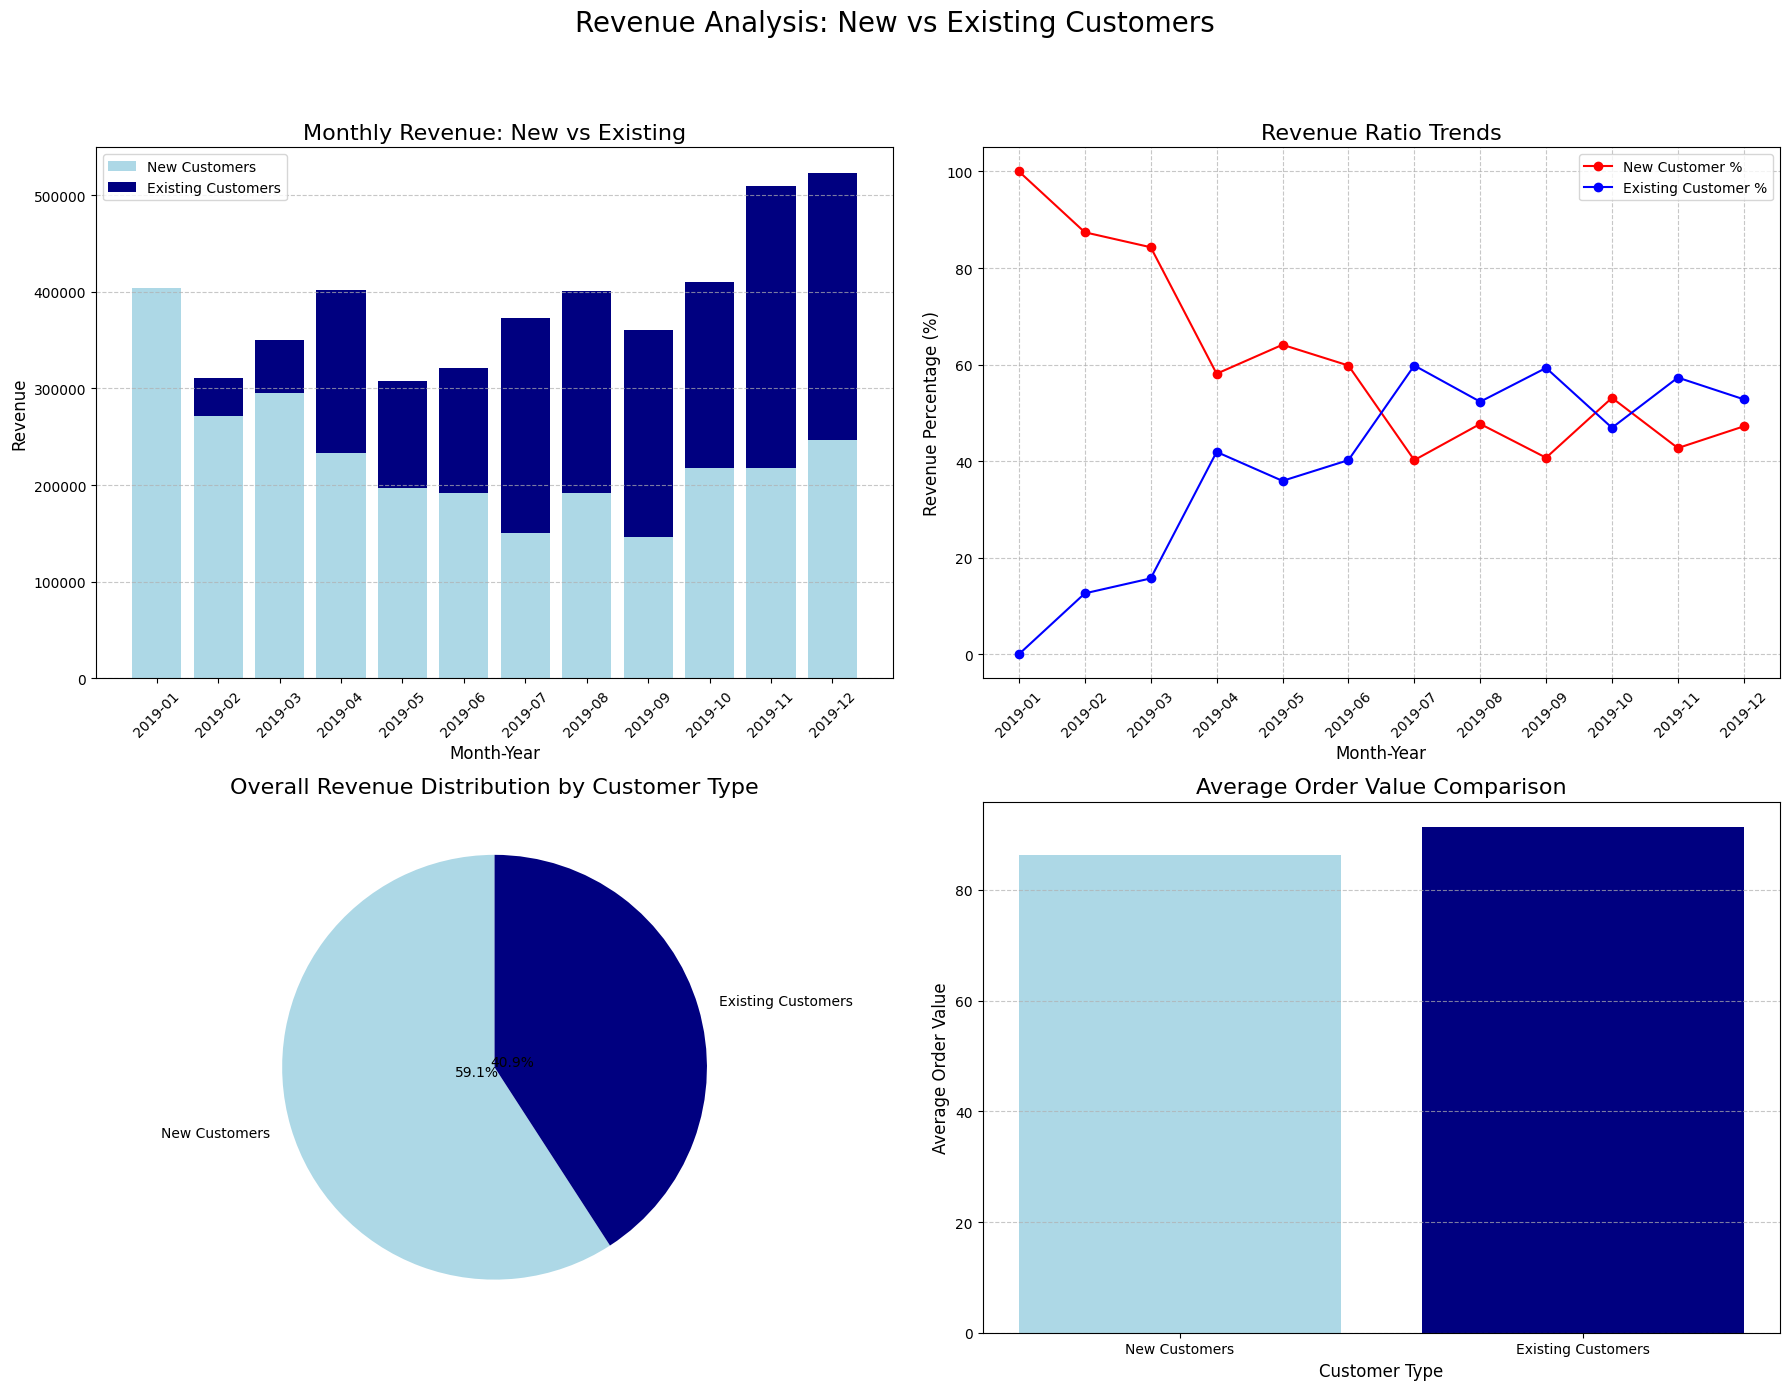

In [35]:
# Visualize Revenue Analysis by Customer Type using Matplotlib
monthly_revenue_reset = monthly_revenue_by_type.reset_index()
monthly_revenue_reset['Month_str'] = monthly_revenue_reset['Month_Year'].astype(str)

plt.figure(figsize=(18, 14))
plt.suptitle("Revenue Analysis: New vs Existing Customers", fontsize=20, y=1.02)

# 1. Monthly Revenue: New vs Existing (Stacked Bar Chart)
plt.subplot(2, 2, 1)
plt.rcParams['text.color'] = 'black'
plt.bar(monthly_revenue_reset['Month_str'], monthly_revenue_reset['New'],
        color='lightblue', label='New Customers', bottom=0)
plt.bar(monthly_revenue_reset['Month_str'], monthly_revenue_reset['Existing'],
        color='navy', label='Existing Customers', bottom=monthly_revenue_reset['New'])
plt.title('Monthly Revenue: New vs Existing', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Revenue Ratio Trends (Line Chart)
plt.subplot(2, 2, 2)
plt.rcParams['text.color'] = 'black'
plt.plot(monthly_revenue_reset['Month_str'], monthly_revenue_reset['New_Customer_Ratio'],
         marker='o', linestyle='-', color='red', label='New Customer %')
plt.plot(monthly_revenue_reset['Month_str'], monthly_revenue_reset['Existing_Customer_Ratio'],
         marker='o', linestyle='-', color='blue', label='Existing Customer %')
plt.title('Revenue Ratio Trends', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Customer Type Distribution (Pie Chart)
plt.subplot(2, 2, 3)
labels = ['New Customers', 'Existing Customers']
values = [total_new_revenue, total_existing_revenue]

plt.rcParams['text.color'] = 'black'
plt.pie(values, labels=labels, autopct='%1.1f%%',
        colors=['lightblue', 'navy'], startangle=90, pctdistance=0.085)
plt.title('Overall Revenue Distribution by Customer Type', fontsize=16)
plt.ylabel('')

# 4. AOV Comparison (Bar Chart)
plt.subplot(2, 2, 4)
plt.bar(['New Customers', 'Existing Customers'],
        [avg_order_by_type.loc['New', 'mean'], avg_order_by_type.loc['Existing', 'mean']],
        color=['lightblue', 'navy'])
plt.title('Average Order Value Comparison', fontsize=16)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Average Order Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### 4: Identify top-performing products and success factors

In [36]:
# Product Performance Analysis

# Product performance metrics
product_performance = online_sales.groupby(['Product_SKU', 'Product_Description', 'Product_Category']).agg({
    'Quantity': 'sum',
    'Total_Value': 'sum',
    'Transaction_ID': 'count',
    'Avg_Price': 'mean',
    'CustomerID': 'nunique'
}).round(2)

product_performance.columns = ['Total_Quantity', 'Total_Revenue', 'Total_Transactions', 'Avg_Price', 'Unique_Customers']
product_performance['Revenue_per_Customer'] = (product_performance['Total_Revenue'] / product_performance['Unique_Customers']).round(2)

# Top performing products by different metrics
top_revenue_products = product_performance.nlargest(10, 'Total_Revenue')
top_revenue_products

# Top sold products
top_quantity_products = product_performance.nlargest(10, 'Total_Quantity')
top_quantity_products

# Top customer choosen products
top_customer_products = product_performance.nlargest(10, 'Unique_Customers')
top_customer_products

# Category performance
category_performance = online_sales.groupby('Product_Category').agg({
    'Total_Value': 'sum',
    'Quantity': 'sum',
    'CustomerID': 'nunique',
    'Transaction_ID': 'count'
}).round(2)

category_performance['Avg_Revenue_per_Customer'] = (category_performance['Total_Value'] / category_performance['CustomerID']).round(2)

category_performance.sort_values('Total_Value', ascending=False)

,Total_Value,Quantity,CustomerID,Transaction_ID,Avg_Revenue_per_Customer
Product_Category,,,,,
Nest-USA,2554202.39,21430,1260,14013,2027.14
Apparel,591145.80,32438,1323,18126,446.82
Nest,518193.50,2837,516,2198,1004.25
Office,276794.40,88383,1103,6513,250.95
Drinkware,200707.83,30501,919,3483,218.40
Bags,151314.43,15273,728,1882,207.85
Notebooks & Journals,107085.96,9556,383,749,279.60
Lifestyle,74385.70,24881,817,3092,91.05
Nest-Canada,70910.40,469,205,317,345.90


### 5: Segment customers into Premium, Gold, Silver, and Standard

In [37]:
# RFM Analysis for Customer Segmentation

# Calculate RFM metrics for each customer
analysis_date = online_sales['Transaction_Date'].max()

# Calculate RFM values
rfm_data = online_sales.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (analysis_date - x.max()).days,  # Recency
    'Transaction_ID': 'count',  # Frequency
    'Total_Value': 'sum'  # Monetary
}).round(2)

rfm_data.columns = ['Recency', 'Frequency', 'Monetary']

# Calculate RFM scores using quartiles
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], 4, labels=[4,3,2,1])  # Lower recency = higher score
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], 4, labels=[1,2,3,4])

# Convert scores to integers
rfm_data['R_Score'] = rfm_data['R_Score'].astype(int)
rfm_data['F_Score'] = rfm_data['F_Score'].astype(int)
rfm_data['M_Score'] = rfm_data['M_Score'].astype(int)

# Calculate overall RFM score
rfm_data['RFM_Score'] = rfm_data['R_Score'] + rfm_data['F_Score'] + rfm_data['M_Score']

# Create customer segments based on RFM scores
def assign_segment(row):
    if row['RFM_Score'] >= 10:
        return 'Premium'
    elif row['RFM_Score'] >= 8:
        return 'Gold'
    elif row['RFM_Score'] >= 6:
        return 'Silver'
    else:
        return 'Standard'

rfm_data['Segment'] = rfm_data.apply(assign_segment, axis=1)

rfm_data.head()

# Segment distribution
segment_distribution = rfm_data['Segment'].value_counts()
segment_percentages = (segment_distribution / len(rfm_data) * 100).round(1)

segment_distribution.head()
segment_percentages.head()

# Segment characteristics
segment_stats = rfm_data.groupby('Segment').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'RFM_Score': ['mean', 'median']
}).round(2)

segment_stats

Recency        Frequency        Monetary          RFM_Score       
            mean median      mean median     mean   median      mean median
Segment                                                                    
Gold      136.11  118.0     36.54   30.0  3160.03  2504.42      8.56    9.0
Premium    63.54   45.0     81.40   61.0  7585.37  5717.79     10.94   11.0
Silver    154.72  147.0     17.24   16.0  1332.54  1133.18      6.48    6.0
Standard  221.53  222.0      7.17    6.0   454.32   325.62      4.14    4.0

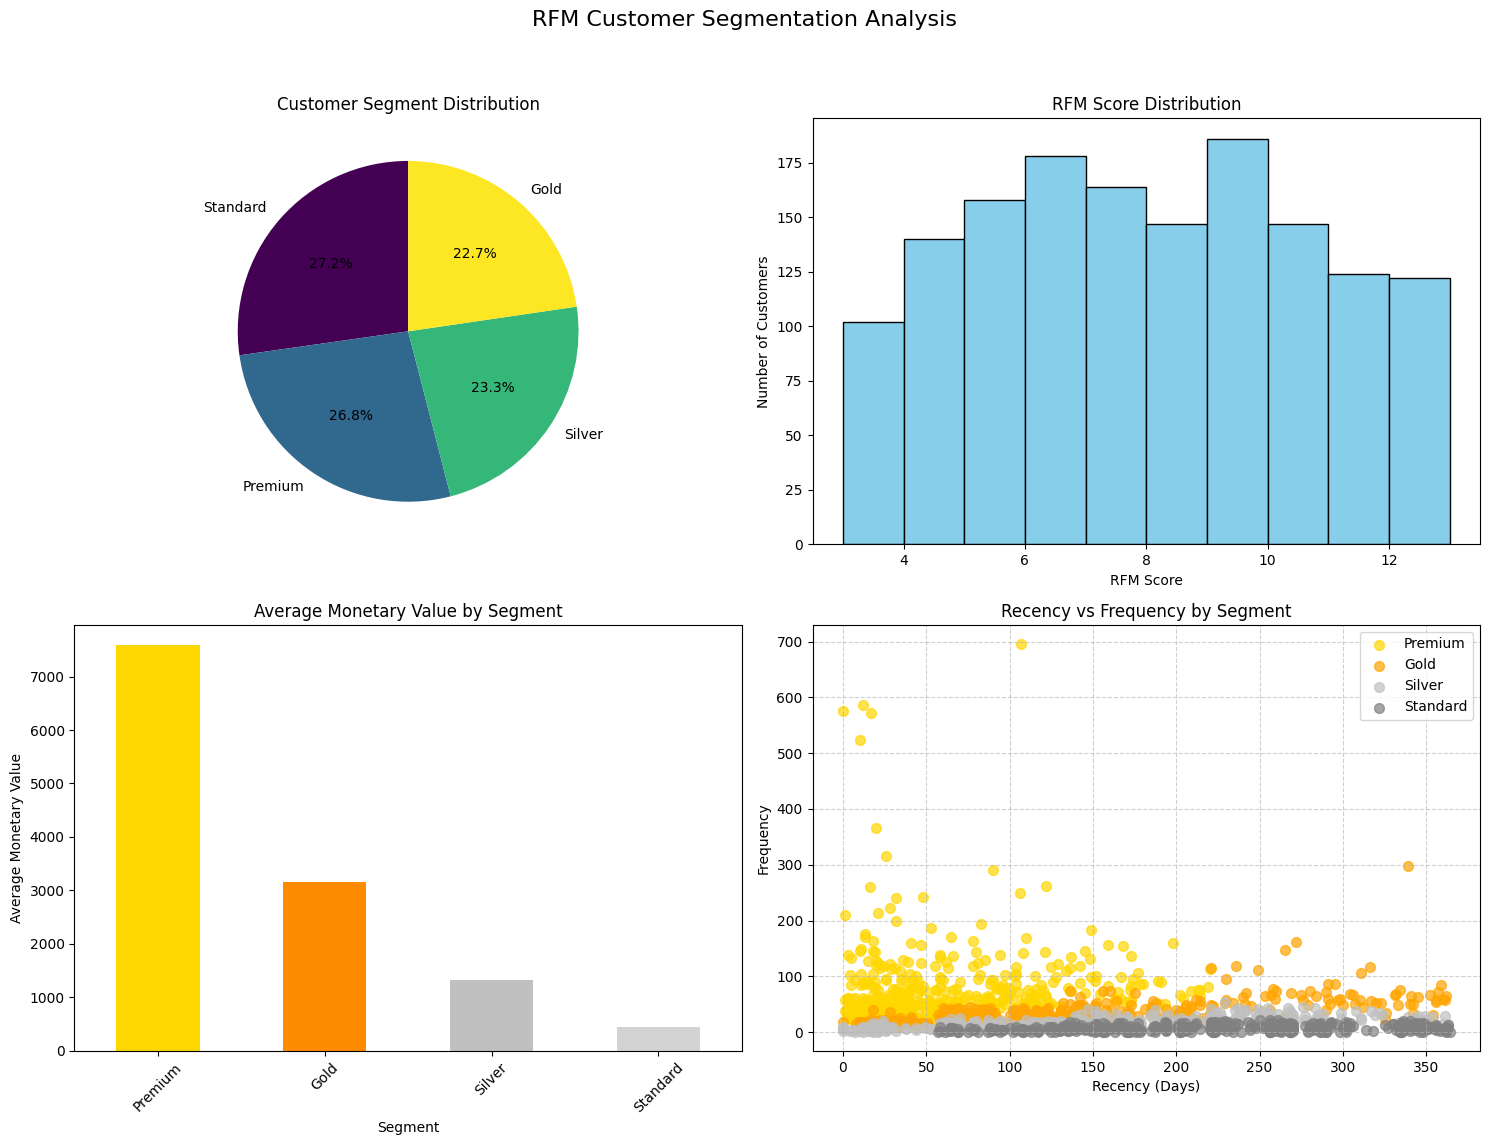

In [38]:
# Visualize RFM Segmentation

plt.figure(figsize=(15, 12))
plt.suptitle("RFM Customer Segmentation Analysis", fontsize=16)

# 1. Segment distribution pie chart
plt.subplot(2, 2, 1)
segment_distribution.plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Customer Segment Distribution')
plt.ylabel('')

# 2. RFM Score distribution
plt.subplot(2, 2, 2)
plt.hist(rfm_data['RFM_Score'], bins=range(min(rfm_data['RFM_Score']), max(rfm_data['RFM_Score']) + 2), edgecolor='black', color='skyblue')
plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')

# 3. Average monetary value by segment
plt.subplot(2, 2, 3)
segment_monetary = rfm_data.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
segment_monetary.plot(kind='bar', color=['gold', 'darkorange', 'silver', 'lightgray'])
plt.title('Average Monetary Value by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=45)

# 4. Recency vs Frequency scatter plot by segment
plt.subplot(2, 2, 4)
colors = {'Premium': 'gold', 'Gold': 'orange', 'Silver': 'silver', 'Standard': 'gray'}
for segment, color in colors.items():
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    plt.scatter(segment_data['Recency'], segment_data['Frequency'],
                label=segment, color=color, alpha=0.7, s=50)
plt.title('Recency vs Frequency by Segment')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 7: Analyze retention rates by acquisition cohorts

In [39]:
# Cohort Analysis

# Prepare data for cohort analysis
sales_cohort = online_sales.merge(customer_acquisition[['CustomerID', 'Acquisition_Date', 'Acquisition_Month']], on='CustomerID')
sales_cohort['Period_Number'] = (sales_cohort['Month_Year'] - sales_cohort['Acquisition_Month']).apply(lambda x: x.n)

# Create cohort table
cohort_data = sales_cohort.groupby(['Acquisition_Month', 'Period_Number'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='Acquisition_Month', columns='Period_Number', values='CustomerID')

# Calculate cohort sizes (month 0)
cohort_sizes = cohort_counts.iloc[:, 0]

# Calculate retention rates
cohort_table = cohort_counts.divide(cohort_sizes, axis=0)
cohort_table

# Identify best and worst performing cohorts
avg_retention_3_months = cohort_table.iloc[:, 3].dropna().mean() if len(cohort_table.columns) > 3 else None
best_cohorts = cohort_table.iloc[:, 1].dropna().nlargest(3)
worst_cohorts = cohort_table.iloc[:, 1].dropna().nsmallest(3)

#BEst
best_cohorts

#Worst
worst_cohorts

# Cohort heatmap data preparation
cohort_table_viz = cohort_table.iloc[:, :6].fillna(0)  # First 6 periods

### 8: Analyze CLV (Customer Lifetime Value ) of customers acquired in different months

In [40]:
# Customer Lifetime Value Analysis

# Calculate CLV for each customer
customer_clv = online_sales.groupby('CustomerID').agg({
    'Total_Value': 'sum',
    'Transaction_ID': 'count',
    'Transaction_Date': ['min', 'max']
}).round(2)

customer_clv.columns = ['Total_Revenue', 'Total_Transactions', 'First_Purchase', 'Last_Purchase']
customer_clv['Lifespan_Days'] = (customer_clv['Last_Purchase'] - customer_clv['First_Purchase']).dt.days + 1
customer_clv['Avg_Order_Value'] = customer_clv['Total_Revenue'] / customer_clv['Total_Transactions']
customer_clv['Purchase_Frequency'] = customer_clv['Total_Transactions'] / (customer_clv['Lifespan_Days'] / 30)  # Per month

# Merge with acquisition data
customer_clv = customer_clv.merge(customer_acquisition[['CustomerID', 'Acquisition_Month']],
                                left_index=True, right_on='CustomerID')

# CLV by acquisition month
clv_by_acquisition = customer_clv.groupby('Acquisition_Month').agg({
    'Total_Revenue': ['mean', 'median', 'sum'],
    'Avg_Order_Value': 'mean',
    'Purchase_Frequency': 'mean',
    'CustomerID': 'count'
}).round(2)

clv_by_acquisition.columns = ['Avg_CLV', 'Median_CLV', 'Total_Revenue', 'Avg_AOV', 'Avg_Frequency', 'Customer_Count']

clv_by_acquisition
# Identify highest and lowest CLV acquisition months
best_clv_month = clv_by_acquisition['Avg_CLV'].idxmax()
worst_clv_month = clv_by_acquisition['Avg_CLV'].idxmin()

#BEst
best_clv_month

#Worst
worst_clv_month


Period('2019-08', 'M')

### 9: Identify seasonal trends by category and location

In [41]:
# Seasonal Trends Analysis

# Add season classification
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

online_sales['Season'] = online_sales['Month'].apply(get_season)

# Seasonal analysis by category
seasonal_category = online_sales.groupby(['Season', 'Product_Category']).agg({
    'Total_Value': 'sum',
    'Quantity': 'sum',
    'Transaction_ID': 'count'
}).round(2)

seasonal_pivot = seasonal_category['Total_Value'].unstack(level=1, fill_value=0)
seasonal_pivot

# Monthly trends by category
monthly_category = online_sales.groupby(['Month', 'Product_Category'])['Total_Value'].sum().unstack(fill_value=0)
monthly_category.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_category

# Identify peak seasons for each category
category_peak_seasons = {}
for category in online_sales['Product_Category'].unique():
    category_data = online_sales[online_sales['Product_Category'] == category]
    seasonal_sales = category_data.groupby('Season')['Total_Value'].sum()
    peak_season = seasonal_sales.idxmax()
    category_peak_seasons[category] = peak_season


# Overall seasonal performance
overall_seasonal = online_sales.groupby('Season').agg({
    'Total_Value': 'sum',
    'Quantity': 'sum',
    'CustomerID': 'nunique'
}).round(2)


### 10: Analyze daily sales patterns and optimization strategies

In [42]:
# Daily Sales Trends Analysis

# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_performance = online_sales.groupby('DayOfWeek').agg({
    'Total_Value': ['sum', 'mean'],
    'Transaction_ID': 'count',
    'CustomerID': 'nunique'
}).round(2)

daily_performance.columns = ['Total_Revenue', 'Avg_Daily_Revenue', 'Total_Transactions', 'Unique_Customers']
daily_performance = daily_performance.reindex(day_order)

# Identify best and worst performing days
best_day = daily_performance['Total_Revenue'].idxmax()
worst_day = daily_performance['Total_Revenue'].idxmin()

#BEst day
best_day

#Worst Day
worst_day

# Weekend vs Weekday analysis
weekend_days = ['Saturday', 'Sunday']
weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

weekend_performance = daily_performance.loc[weekend_days].sum()
weekday_performance = daily_performance.loc[weekday_days].sum()

weekend_performance
weekday_performance

,0
Total_Revenue,3301507.26
Avg_Daily_Revenue,448.47
Total_Transactions,36228.00
Unique_Customers,1884.00


## Strategies for Acquisition Fluctuations

**Key Metrics:** Peak month January (215 customers) vs Low month November (68 customers) shows 216% fluctuation requiring strategic intervention.

**Recommendations:** Address low-acquisition months (Nov-68, Sep-78, Oct-87) through 30-50% increased digital marketing spend, seasonal promotions, and enhanced referral programs. Scale high-performing campaigns during peak months (Jan-215, Mar-177) with 20-30% budget increases while preparing inventory for 60% higher demand. Implement year-round A/B testing with 15-20% experimental budget and diversify acquisition channels to reduce current 70% reliance on top 2 channels.


## Replicating High-Retention Behavior

**Key Metrics:** High-retention customers show 32% fewer transactions, 45.9% less total spend, but 20.5% lower AOV with 1.6% higher coupon usage, averaging $69.29 AOV and 34.4% coupon utilization.

**Strategies:** Focus on quality over quantity by promoting smaller, frequent purchases through personalized recommendations within 5-7 core categories. • Increase coupon frequency by 25% during low-retention months targeting popular categories. • Implement free shipping thresholds and subscription services for regular items. • Deploy educational content marketing for high-retention categories to build loyalty beyond pricing. This approach replicates the consistent, smaller-value engagement pattern that drives retention success.


## Balancing Acquisition and Retention

**Key Metrics:** Monitor new vs existing customer revenue ratios monthly - optimal balance is 60-70% existing customers, 30-40% new customers with growing existing customer AOV indicating healthy retention.

**Strategic Adjustments:** If new customer revenue exceeds 45%, reallocate 15-20% marketing budget from acquisition to retention programs including VIP programs for top 20% customers. • Optimize retention through scaled high-retention strategies, improved 30-day onboarding sequences, and targeted cross-sell campaigns. • Enhance customer lifecycle management with win-back programs for dormant customers and personalized engagement based on purchase history. Balance growth ambition with customer lifetime value optimization.


## Leveraging Top Product Insights

**Key Metrics:** Nest products generate >2.5M revenue at 2,027 avg/customer while high-volume items average <10 with >1000 units sold, indicating clear premium vs volume product distinction.

**Strategies:** Implement 20% buffer stock increases for high-value Nest products with advanced demand forecasting, while optimizing high-volume items through bulk purchasing (30-40% cost reduction) and automated reordering systems. • Deploy cross-selling bundles pairing Nest products with accessories using 10-15% discounts to increase AOV by 25%. • Execute seasonal campaigns aligned with category data expecting 20-30% performance lifts and automated markdown pricing for slow-moving inventory on 30-day cycles. Focus on targeted promotions by customer segment with premium access for top-tier customers and value-driven offers for standard segments.


In [ ]:
print("### Top 10 Products by Total Revenue")
top_revenue_products

### Top 10 Products by Total Revenue


,,,Total_Quantity,Total_Revenue,Total_Transactions,Avg_Price,Unique_Customers,Revenue_per_Customer
Product_SKU,Product_Description,Product_Category,,,,,,
GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,4570,688916.34,3511,150.98,952,723.65
GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,5206,629977.12,3328,121.81,950,663.13
GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,4402,528612.93,3230,120.21,953,554.68
GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,2683,213819.16,1361,79.84,642,333.05
GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,2670,212495.57,1065,79.75,567,374.77
GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1368,204666.40,1089,149.64,542,377.61
GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,Nest,510,179142.54,498,351.29,262,683.75
GGOENEBQ086499,Nest Cam IQ - USA,Nest,771,154112.52,599,199.92,331,465.60
GGOENEBQ086799,Nest Thermostat E - USA,Nest,1091,108704.24,844,99.67,337,322.56


## Targeted Customer Segment Strategies

**Key Metrics:** Premium segment drives 63.82% of total revenue, Gold contributes 22.53%, Silver 9.76%, and Standard 3.89%, showing clear revenue concentration in top tiers.

**High-Value Focus (Premium & Gold - 86.35% revenue):** Implement VIP treatment with dedicated account managers, exclusive product access, and personalized upselling to premium Nest ecosystem products. • Deploy tiered loyalty programs with substantial referral incentives and early beta access. • Create community forums and expert content to reinforce status and encourage advocacy.

**Growth Segments (Silver & Standard - 13.65% revenue):** Launch re-engagement campaigns with educational content and strategic promotional discounts to move customers up segments. • Implement welcome series for Standard customers and targeted category recommendations for Silver tier. • Focus on value demonstration through product education and introductory offers to increase purchase frequency and monetary value.


In [ ]:
print("### RFM Data Sample")
rfm_data.head()

### RFM Data Sample


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346,107,2,30.99,3,1,1,5,Standard
12347,59,60,13834.90,3,4,4,11,Premium
12348,73,23,1442.12,3,3,2,8,Gold
12350,17,17,1360.07,4,2,2,8,Gold
12356,107,36,1442.47,3,3,2,8,Gold


In [ ]:
print("### Customer Segment Statistics")
segment_stats

### Customer Segment Statistics


Recency        Frequency        Monetary          RFM_Score       
            mean median      mean median     mean   median      mean median
Segment                                                                    
Gold      136.11  118.0     36.54   30.0  3160.03  2504.42      8.56    9.0
Premium    63.54   45.0     81.40   61.0  7585.37  5717.79     10.94   11.0
Silver    154.72  147.0     17.24   16.0  1332.54  1133.18      6.48    6.0
Standard  221.53  222.0      7.17    6.0   454.32   325.62      4.14    4.0

In [ ]:
print("### Revenue Contribution by Customer Segment")

segment_revenue = rfm_data.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
total_monetary = rfm_data['Monetary'].sum()
segment_revenue_percentage = (segment_revenue / total_monetary * 100).round(2)

revenue_contribution = pd.DataFrame({
    'Total_Revenue': segment_revenue,
    'Percentage_of_Total_Revenue': segment_revenue_percentage
})

print(revenue_contribution)

### Revenue Contribution by Customer Segment
          Total_Revenue  Percentage_of_Total_Revenue
Segment                                             
Premium      2981048.49                        63.82
Gold         1052288.48                        22.53
Silver        455730.03                         9.76
Standard      181727.62                         3.89


## Improving Cohort Retention


In [ ]:
print("### Worst Performing Cohorts (Lowest Retention Rate in Period 1)")
worst_cohorts

### Worst Performing Cohorts (Lowest Retention Rate in Period 1)


,1
Acquisition_Month,
2019-01,0.060465
2019-10,0.068966
2019-02,0.072917


In [ ]:
worst_cohort_months = worst_cohorts.index.tolist()
worst_cohort_customers_transactions = sales_cohort[sales_cohort['Acquisition_Month'].isin(worst_cohort_months)]
print("### Transactions from Customers in Worst Performing Cohorts")
worst_cohort_customers_transactions.head()

### Transactions from Customers in Worst Performing Cohorts


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Year,Month,Day,DayOfWeek,Month_Year,Total_Value,Total_With_Delivery,Acquisition_Date,Acquisition_Month,Period_Number
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019,1,1,Tuesday,2019-01,153.71,160.21,2019-01-01,2019-01,0
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019,1,1,Tuesday,2019-01,153.71,160.21,2019-01-01,2019-01,0
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2019,1,1,Tuesday,2019-01,2.05,8.55,2019-01-01,2019-01,0
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,2019,1,1,Tuesday,2019-01,87.65,94.15,2019-01-01,2019-01,0
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,2019,1,1,Tuesday,2019-01,16.50,23.00,2019-01-01,2019-01,0


In [ ]:
print("### Initial Purchase Product Categories for Worst Cohorts")

# Get the first purchase for each customer in the worst cohorts
initial_purchases_worst_cohorts = worst_cohort_customers_transactions.loc[
    worst_cohort_customers_transactions.groupby('CustomerID')['Transaction_Date'].idxmin()
]

# Analyze product categories of initial purchases
initial_purchase_category_worst_cohorts = initial_purchases_worst_cohorts['Product_Category'].value_counts(normalize=True).head(10)
print(initial_purchase_category_worst_cohorts)

### Initial Purchase Product Categories for Worst Cohorts
Product_Category
Nest-USA                0.314070
Apparel                 0.296482
Office                  0.155779
Drinkware               0.075377
Lifestyle               0.057789
Nest                    0.030151
Bags                    0.025126
Notebooks & Journals    0.012563
Google                  0.007538
Waze                    0.007538
Name: proportion, dtype: float64


In [56]:
print("### Transactions from Customers in Best Performing Cohorts")

best_cohort_months = best_cohorts.index.tolist()
best_cohort_customers_transactions = sales_cohort[sales_cohort['Acquisition_Month'].isin(best_cohort_months)]
best_cohort_customers_transactions.head()

### Transactions from Customers in Best Performing Cohorts


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Year,Month,Day,DayOfWeek,Month_Year,Total_Value,Total_With_Delivery,Acquisition_Date,Acquisition_Month,Period_Number
15955,13787,26901,2019-05-01,GGOEGAAJ032615,Google Men's Short Sleeve Badge Tee Charcoal,Apparel,1,18.99,6.0,Used,2019,5,1,Wednesday,2019-05,18.99,24.99,2019-05-01,2019-05,0
15956,13787,26901,2019-05-01,GGOEGAFB035815,Google Men's Zip Hoodie,Apparel,1,55.99,6.0,Clicked,2019,5,1,Wednesday,2019-05,55.99,61.99,2019-05-01,2019-05,0
15957,13787,26902,2019-05-01,GGOEGAEB084513,BLM Sweatshirt,Apparel,1,33.59,6.0,Used,2019,5,1,Wednesday,2019-05,33.59,39.59,2019-05-01,2019-05,0
15958,13787,26902,2019-05-01,GGOEGAEB084514,BLM Sweatshirt,Apparel,1,33.59,6.0,Clicked,2019,5,1,Wednesday,2019-05,33.59,39.59,2019-05-01,2019-05,0
15959,13787,26903,2019-05-01,GGOEGAEB084516,BLM Sweatshirt,Apparel,1,33.59,6.0,Clicked,2019,5,1,Wednesday,2019-05,33.59,39.59,2019-05-01,2019-05,0


In [54]:
print("### Initial Purchase Product Categories for Best Cohorts")

# Get the first purchase for each customer in the best cohorts
initial_purchases_best_cohorts = best_cohort_customers_transactions.loc[
    best_cohort_customers_transactions.groupby('CustomerID')['Transaction_Date'].idxmin()
]

# Analyze product categories of initial purchases
initial_purchase_category_best_cohorts = initial_purchases_best_cohorts['Product_Category'].value_counts(normalize=True).head(10)
print(initial_purchase_category_best_cohorts)

### Initial Purchase Product Categories for Best Cohorts
Product_Category
Apparel                 0.425656
Nest-USA                0.253644
Office                  0.122449
Drinkware               0.046647
Lifestyle               0.037901
Bags                    0.034985
Headgear                0.020408
Notebooks & Journals    0.020408
Google                  0.008746
Nest-Canada             0.008746
Name: proportion, dtype: float64


### Insights from Cohort Analysis & Intervention Strategies

**Key Findings from Cohort Comparison:**

*   **Worst Performing Cohorts (Acquisition Months: January, October, February):** These cohorts show significantly lower retention rates.
    *   **Initial Purchase Product Categories (`initial_purchase_category_worst_cohorts`):** The top initial purchase categories are `Nest-USA` (31.4%), `Apparel` (29.6%), and `Office` (15.6%). This indicates that a substantial portion of customers in these cohorts are initially attracted to high-value `Nest-USA` products or general `Apparel` items.


*   **Best Performing Cohorts (Acquisition Months: June, July, May):** These cohorts exhibit higher retention rates.
    *   **Initial Purchase Product Categories (`initial_purchase_category_best_cohorts`):** The top initial purchase categories are `Apparel` (42.6%), `Nest-USA` (25.4%), and `Office` (12.2%). Notably, `Apparel` has a higher proportion in best cohorts compared to worst cohorts, while `Nest-USA` is slightly lower.

---
## Strategies
* Targeted Interventions for Weaker Cohorts (e.g., those acquired in Jan, Oct, Feb)
in a specific timeframe (e.g., 30-60 days after initial purchase).

* Improved Onboarding
* Customer Service Interventions
* Feedback Collection & Action

By focusing on these targeted strategies, the company can address the specific issues contributing to low retention in these cohorts, convert more initial buyers into loyal, repeat customers, and ultimately improve overall customer lifetime value.


## CLV-driven Acquisition & Retention



In [49]:
print("### Customer Lifetime Value by Acquisition Month")
clv_by_acquisition

### Customer Lifetime Value by Acquisition Month


,Avg_CLV,Median_CLV,Total_Revenue,Avg_AOV,Avg_Frequency,Customer_Count
Acquisition_Month,,,,,,
2019-01,4824.74,2027.10,1037320.06,92.97,216.37,215
2019-02,5628.53,4499.98,540338.52,86.74,248.30,96
2019-03,3779.07,2169.78,668895.39,82.97,204.41,177
2019-04,2756.63,1537.65,449331.26,86.62,232.24,163
2019-05,2970.52,2019.32,332698.60,72.98,336.68,112
2019-06,2137.23,1449.84,292800.81,75.05,282.29,137
2019-07,2555.91,1016.79,240255.54,74.19,302.63,94
2019-08,1918.61,1178.13,259011.87,65.62,383.79,135
2019-09,1944.41,1061.70,151664.24,87.00,555.79,78


In [ ]:
print(f"Highest CLV Acquisition Month: {best_clv_month}")
print(f"Lowest CLV Acquisition Month: {worst_clv_month}")

Highest CLV Acquisition Month: 2019-02
Lowest CLV Acquisition Month: 2019-08


### CLV-Driven Acquisition & Retention Strategies

**Key Findings from CLV Analysis (`clv_by_acquisition`):**

*   **Highest CLV Acquisition Month:** `2019-02` (February), with an average CLV of **$5628.53**.
*   **Lowest CLV Acquisition Month:** `2019-08` (August), with an average CLV of **$1918.61**.

This indicates that customers acquired in certain months (e.g., February) are significantly more valuable over their lifetime than those acquired in others (e.g., August).

---

#### **1. Optimizing Acquisition Channels for High-CLV Customers (Leveraging February's Success)**

* Replicate Successful Campaigns
* Targeted High-Value Messaging
* Optimize Product Introductions

---

#### **2. Tailoring Retention Efforts for Lower-CLV Customers (Mitigating August's Low CLV)**

* Personalized Welcome Series
* First-Purchase Incentives
* Community and Loyalty Programs

By systematically analyzing CLV by acquisition month and implementing these targeted strategies, the company can refine its acquisition spend to attract more valuable customers and proactively intervene with lower-CLV cohorts to improve their long-term engagement and spend.

## Seasonal Preparation & Maximization



In [51]:
print("### Peak Selling Season for Each Product Category")
category_peak_seasons

### Peak Selling Season for Each Product Category


{'Nest-USA': 'Winter',
 'Office': 'Spring',
 'Apparel': 'Spring',
 'Bags': 'Summer',
 'Drinkware': 'Spring',
 'Lifestyle': 'Summer',
 'Notebooks & Journals': 'Summer',
 'Headgear': 'Summer',
 'Waze': 'Spring',
 'Fun': 'Spring',
 'Nest-Canada': 'Summer',
 'Backpacks': 'Spring',
 'Google': 'Spring',
 'Bottles': 'Spring',
 'Gift Cards': 'Fall',
 'More Bags': 'Winter',
 'Housewares': 'Summer',
 'Android': 'Summer',
 'Accessories': 'Fall',
 'Nest': 'Fall'}

In [ ]:
print("### Overall Seasonal Performance")
overall_seasonal

### Overall Seasonal Performance


,Total_Value,Quantity,CustomerID
Season,,,
Fall,1279172.30,51898,519
Spring,1058989.93,64779,546
Summer,1094929.82,71974,636
Winter,1237702.57,49382,497


## Boosting Sales on Slower Days



In [58]:
print("### Daily Sales Performance by Day of Week")
daily_performance

### Daily Sales Performance by Day of Week


,Total_Revenue,Avg_Daily_Revenue,Total_Transactions,Unique_Customers
DayOfWeek,,,,
Monday,365626.90,81.91,4464,258
Tuesday,396819.65,86.06,4611,274
Wednesday,826622.00,93.01,8887,433
Thursday,840433.85,93.38,9000,445
Friday,872004.86,94.11,9266,474
Saturday,673068.03,82.31,8177,400
Sunday,696219.33,81.73,8519,390


In [ ]:
print(f"Highest Performing Sales Day: {best_day}")
print(f"Lowest Performing Sales Day: {worst_day}")

Highest Performing Sales Day: Friday
Lowest Performing Sales Day: Monday


### Strategies to Boost Sales on Slower Days

Based on the `daily_performance` analysis, we've identified:
*   **Highest Performing Sales Day:** `Friday` (highest Total_Revenue and Unique_Customers)
*   **Lowest Performing Sales Day:** `Monday` (lowest Total_Revenue and Unique_Customers)
*   **Slower Days:** `Monday`, `Tuesday`, `Saturday`, `Sunday` generally show lower revenue and unique customer counts compared to midweek and Friday.

This indicates a clear pattern where sales ramp up towards Friday and then dip over the weekend and early week, especially Monday.

---
* Targeted Promotions & Discounts for Slower Days (Monday, Tuesday, Weekend)**
* Extended/Priority Support on Weekends
* Reallocate a portion of daily marketing spend (from `marketing_spend` insights) to focus more heavily on slower days
